# Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("HR_Attrition.csv")

print(" First 10 Rows ")
display(df.head(10))

print("\n Dataset Shape ")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n Target Column ")
print("Attrition")

print("\n Employees Stayed vs Left ")
print(df["Attrition"].value_counts())

employees_left = (df["Attrition"] == "Yes").sum()
attrition_rate = (employees_left / len(df)) * 100

print("\n Attrition Rate ")
print(round(attrition_rate, 2), "%")

numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

print("\n Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

print("\n Observation ")
print("The dataset is imbalanced because employees who stayed are much higher than employees who left.")

 First 10 Rows 


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7



 Dataset Shape 
Rows: 1470
Columns: 35

 Target Column 
Attrition

 Employees Stayed vs Left 
Attrition
No     1233
Yes     237
Name: count, dtype: int64

 Attrition Rate 
16.12 %

 Numeric Columns: 26
Categorical Columns: 9

 Observation 
The dataset is imbalanced because employees who stayed are much higher than employees who left.


# Task 2 — Data Cleaning & Preprocessing

In [2]:
from sklearn.preprocessing import StandardScaler

print("Missing Values:")
print(df.isnull().sum())

df = df.drop(
    ['EmployeeNumber', 'Over18', 'StandardHours'],
    axis=1
)

df['Attrition'] = df['Attrition'].map({
    'Yes': 1,
    'No': 0
})

categorical_cols = df.select_dtypes(include='object').columns

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

scaler = StandardScaler()

numeric_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop('Attrition')

df_encoded[numeric_cols] = scaler.fit_transform(
    df_encoded[numeric_cols]
)

print("\nShape after Encoding and Scaling:")
print(df_encoded.shape)

display(df_encoded.head())

Missing Values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole      

C:\Users\yashi\AppData\Local\Temp\ipykernel_1612\870523744.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,1,0.742527,-1.010909,-0.891688,0.0,-0.660531,1.383138,0.379672,-0.057788,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,0,-1.297775,-0.147150,-1.868426,0.0,0.254625,-0.240677,-1.026167,-0.057788,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1,1.414363,-0.887515,-0.891688,0.0,1.169781,1.284725,-1.026167,-0.961486,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746
3,-0.429664,0,1.461466,-0.764121,1.061787,0.0,1.169781,-0.486709,0.379672,-0.961486,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746
4,-1.086676,0,-0.524295,-0.887515,-1.868426,0.0,-1.575686,-1.274014,0.379672,-0.961486,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241


# Task 3 — Exploratory Data Analysis — EDA

In [3]:
# Attrition by Department

department_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100

print("Department Wise Attrition (%)")
display(department_attrition.round(2))

Department Wise Attrition (%)


Attrition,0,1
Department,,
Human Resources,80.95,19.05
Research & Development,86.16,13.84
Sales,79.37,20.63


In [4]:
# Attrition by Job Role

jobrole_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
) * 100

print("Job Role Wise Attrition (%)")
display(jobrole_attrition.round(2))

Job Role Wise Attrition (%)


Attrition,0,1
JobRole,,
Healthcare Representative,93.13,6.87
Human Resources,76.92,23.08
Laboratory Technician,76.06,23.94
Manager,95.10,4.90
Manufacturing Director,93.10,6.90
Research Director,97.50,2.50
Research Scientist,83.90,16.10
Sales Executive,82.52,17.48
Sales Representative,60.24,39.76


In [5]:
# Attrition vs Monthly Income

income_attrition = df.groupby('Attrition')['MonthlyIncome'].mean()

print("Average Monthly Income")
display(income_attrition.round(2))

Average Monthly Income


Attrition
0    6832.74
1    4787.09
Name: MonthlyIncome, dtype: float64

In [6]:
# Attrition vs Work Life Balance

wlb_attrition = pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition'],
    normalize='index'
) * 100

print("Work Life Balance vs Attrition (%)")
display(wlb_attrition.round(2))

Work Life Balance vs Attrition (%)


Attrition,0,1
WorkLifeBalance,,
1,68.75,31.25
2,83.14,16.86
3,85.78,14.22
4,82.35,17.65


In [7]:
# Attrition vs Years at Company

years_attrition = df.groupby('Attrition')['YearsAtCompany'].mean()

print("Average Years at Company")
display(years_attrition.round(2))

Average Years at Company


Attrition
0    7.37
1    5.13
Name: YearsAtCompany, dtype: float64

### Business Insights

1. Sales department has the highest attrition rate (20.63%).

2. Sales Representatives have the highest attrition rate (39.76%).

3. Employees who left earned an average monthly income of ₹4,787 compared to ₹6,833 for employees who stayed.

4. Employees with Work-Life Balance rating 1 had the highest attrition rate (31.25%).

5. Employees who left stayed for an average of 5.13 years, while employees who remained stayed for 7.37 years.

# Task 4 — Model Building & Comparison

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import pandas as pd
import numpy as np

X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000)
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
gb_model = GradientBoostingClassifier(random_state=42) 

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(lr_model.coef_[0])
}).sort_values(by='Importance', ascending=False)

# Task 5 — Model Evaluation

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1-Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, gb_model.predict_proba(X_test)[:,1])
    ]
})

results = results.round(3)

print("Model Comparison Table")
display(results)

Model Comparison Table


,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.256,0.590,0.357,0.766
1,Random Forest,1.000,0.077,0.143,0.747
2,Gradient Boosting,0.500,0.179,0.264,0.780


**Best Model Observation:**
Logistic Regression performed the best among the three models because it achieved a good balance of Precision and Recall (F1-Score) and a high ROC-AUC score, making its predictions the most reliable for this imbalanced dataset.

# Task 6 — Visualization

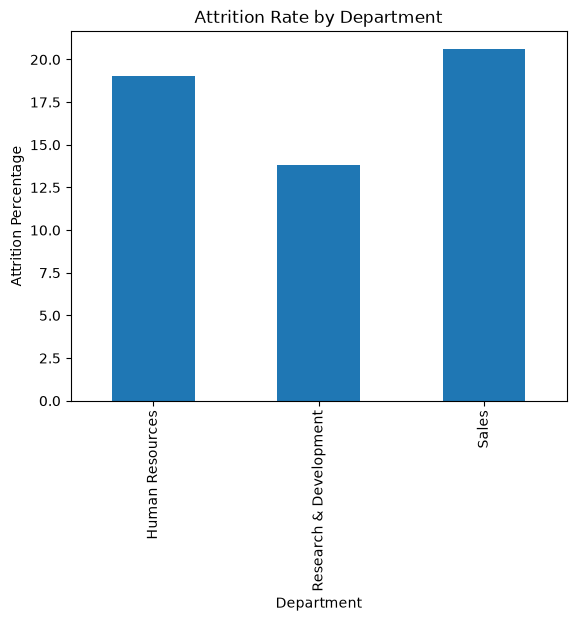

In [10]:
# Bar chart showing attrition rate

import matplotlib.pyplot as plt

dept_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100

dept_attrition[1].plot(kind='bar')

plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Percentage")

plt.savefig("charts/chart1_department_attrition.png", dpi=300)

plt.show()

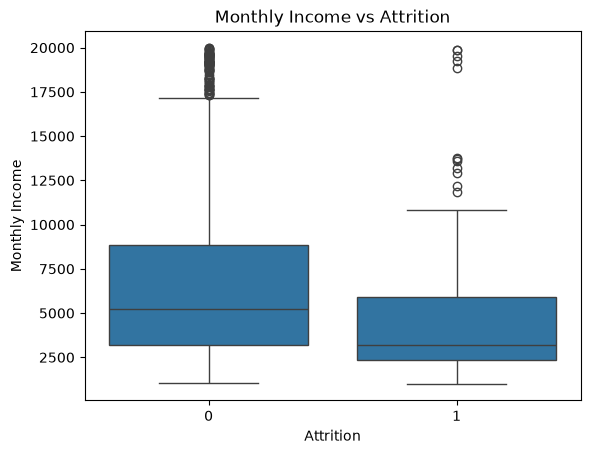

In [11]:
# Box plot comparing Monthly Income of employees who left vs stayed

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.savefig("charts/chart2_income_boxplot.png", dpi=300)
plt.show()

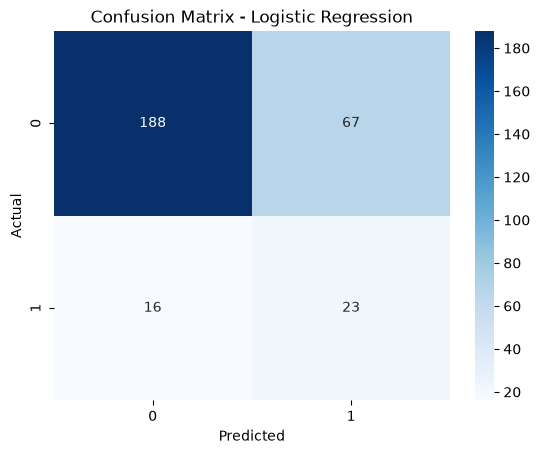

In [12]:
# Confusion Matrix heatmap for your best model

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("charts/chart3_confusion_matrix.png", dpi=300)
plt.show()

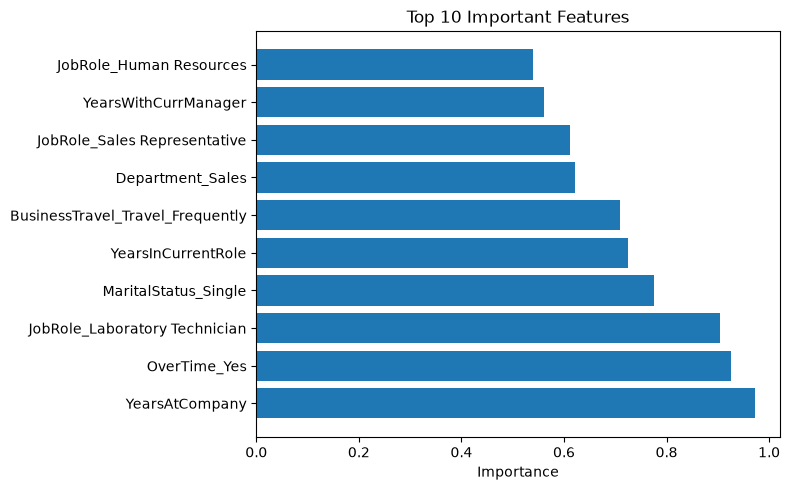

In [13]:
# Horizontal bar chart of Top 10 Feature Importances from your best model

top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("charts/chart4_feature_importance.png", dpi=300)
plt.show()

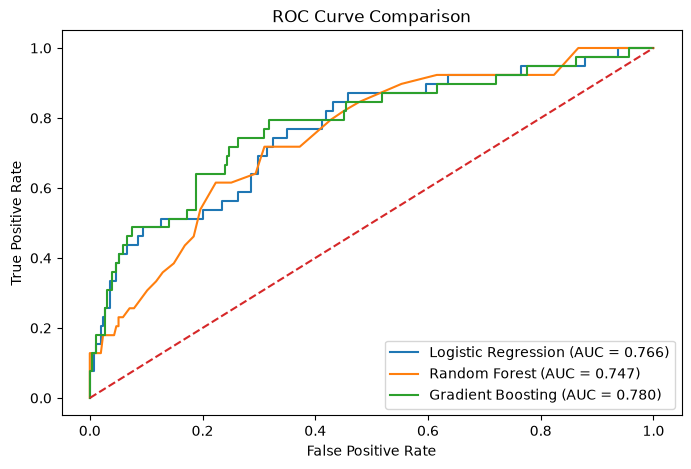

In [14]:
# ROC Curve comparing all 3 models on one graph

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities
lr_prob = lr_model.predict_proba(X_test)[:,1]
rf_prob = rf_model.predict_proba(X_test)[:,1]
gb_prob = gb_model.predict_proba(X_test)[:,1]

# ROC Curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8,5))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, lr_prob):.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})"
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label=f"Gradient Boosting (AUC = {roc_auc_score(y_test, gb_prob):.3f})"
)

plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.savefig("charts/chart5_roc_curve.png", dpi=300)

plt.show()

# Task 7 — HR Insights & Business Recommendations

Based on the analysis, the three strongest factors associated with employee attrition were OverTime, Monthly Income and Years at Company. Employees who worked overtime and had lower monthly income were more likely to leave the company.

The Sales department and Sales Representative role showed the highest attrition rates and should be prioritized for retention efforts. Salary alone does not explain attrition as work life balance and overtime also play an important role.

HR can reduce attrition by improving work-life balance policies and conducting retention discussions with employees who frequently work overtime. Career growth opportunities should also be provided to employees in high attrition roles.

One limitation of this model is that it is based on historical data and cannot fully capture personal or future reasons behind employee decisions.